# Exercise 1: Importance Sampling (1D Adaptive Grid)
+	Define a function named **Vegas_Simple(lower, upper, func, n_points, bins, iterations)** to compute a one-dimensional integral using the Importance Sampling method. The regions of importance are defined by the magnitude of the function.

	Hint:

	**Step 1**: Divide the integration range into a specified number of equal-width bins. (Note: For the first iteration, distribute the n_points uniformly across all bins).

	**Step 2**: For each iteration:
	*	Sample random points within each bin and calculate the bin's integral ($I_{bi}$).
	*	Update the number of points for the next iteration $\sim$ the bin's contribution to the total

	$w_{bin_i} = |\dfrac{I_{bi}}{\sum{I_{bj}}} |$.

	Ensure every bin receives at least 2 points to maintain the grid.

	**Step 3**: Return the final estimate in the form $\bar{I} \pm \sigma_{\bar{I}}$, where 
	$\bar{I}$ is the mean of all iterations and 
	$\sigma_{\bar{I}}$ is the standard error calculated as follow:
	+	For every bin $b_i$, the variance is $(\sigma_{\bar{b_i}})^2 = \dfrac{\sigma_{b_i}^2}{n_i}, n_i$ is the number of points in that bin 
	+	The variance of the total integral for a single iteration $j$: $\sigma_{\bar{I_j}}^2 = \sum_{\text{all bins}} \sigma_{\bar{b_i}}^2$
	+	The standard error after N iterations is $\sigma_{\bar{I}} = \frac{1}{N} * \sqrt{\sum\sigma_{\bar{I_j}}^2} $

+	Using your function to compute the following integral:
	$$ I = \int_{0}^{2 \pi} \sin^2(x)dx$$
+	Verify the result by calculating the absolute error: $|\bar{I} - \pi|$
<!-- +	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases? -->
+	Compare the convergence of the Vegas simple method and the uniform method (using your previous MC_1dim function) by plotting the standard error of both approaches on a log-log scale. Which method has a smaller error? Ensure both methods have the same total number of points (total points = iterations x n_points for Vegas).
+	Modify the Vegas_Simple function so that it returns the results and the total number of random points sampled in each bin across all iterations. Plot the distribution of these points after several iteration steps to observe how the sampling behavior evolves.

## Setup and Imports

In [120]:
import numpy as np
import matplotlib.pyplot as plt

## MC_1dim Function (from Sheet 1)

First, we copy the Monte Carlo integration function from problem sheet 1:

In [121]:
def MC_1dim(lower_bound, upper_bound, func, npoints):
    x = np.random.uniform(lower_bound, upper_bound, npoints)
    
    y = func(x)
    
    I_vals = (upper_bound - lower_bound) * y
    
    I_bar = np.mean(I_vals)
    
    sigma_I = np.std(I_vals, ddof=1)
    
    sigma_I_bar = sigma_I / np.sqrt(npoints)
    
    return I_bar, sigma_I_bar

---
# Exercise 1: Importance Sampling (Vegas Simple)

Implement adaptive importance sampling that redistributes points based on the magnitude of the function.

In [122]:
def VegasSimple(lower, upper, func, npoints, bins, iterations):
    """
    Computes 1D integral using Importance Sampling with adaptive grid.
    
    Parameters:
    -----------
    lower, upper : float
        Integration bounds
    func : callable
        Function to integrate
    npoints : int
        Number of points per iteration
    bins : int
        Number of bins for adaptive grid
    iterations : int
        Number of iterations
        
    Returns:
    --------
    I_mean : float
        Mean estimate of integral over all iterations
    I_std_error : float
        Standard error of the estimate
    points_per_bin : array
        Total number of points sampled in each bin across all iterations
    """
    
    # Initialize bin edges
    bin_edges = np.linspace(lower, upper, bins + 1)
    bin_widths = np.diff(bin_edges)
    
    I_iterations = []
    points_per_bin_total = np.zeros(bins)
    
    # Initial distribution: equal points per bin
    points_per_bin = np.full(bins, max(2, npoints // bins))
    
    for iteration in range(iterations):
        I_bins = np.zeros(bins)
        var_bins = np.zeros(bins)
        
        # Sample points in each bin and compute integral contribution
        for bi in range(bins):
            n_bi = points_per_bin[bi]
            
            # Generate random points uniformly within this bin
            x_bin = np.random.uniform(bin_edges[bi], bin_edges[bi+1], n_bi)
            y_bin = func(x_bin)
            
            # Integral contribution from this bin
            I_vals_bin = bin_widths[bi] * y_bin
            I_bins[bi] = np.mean(I_vals_bin)
            
            # Variance for this bin
            if n_bi > 1:
                var_bins[bi] = np.var(I_vals_bin, ddof=1) / n_bi
            
            # Track total points per bin
            points_per_bin_total[bi] += n_bi
        
        # Total integral for this iteration
        I_total = np.sum(I_bins)
        I_iterations.append(I_total)
        
        # Redistribute points for next iteration based on bin contributions
        if iteration < iterations - 1:  # Don't redistribute after last iteration
            I_abs = np.abs(I_bins)
            total_I_abs = np.sum(I_abs)
            
            if total_I_abs > 0:
                # Allocate points proportional to |I_bi|
                new_points = (I_abs / total_I_abs) * npoints
                # Ensure minimum 2 points per bin
                points_per_bin = np.maximum(2, new_points.astype(int))
                # Adjust to maintain total npoints
                diff = npoints - np.sum(points_per_bin)
                if diff != 0:
                    # Add/remove from bin with most points
                    idx_max = np.argmax(points_per_bin)
                    points_per_bin[idx_max] += diff
    
    # Compute final estimates
    I_mean = np.mean(I_iterations)
    I_std_error = np.std(I_iterations, ddof=1) / np.sqrt(iterations) if iterations > 1 else 0
    
    return I_mean, I_std_error, points_per_bin_total

### Test the VegasSimple Function

Compute the integral:
$$
I = \int_0^{2\pi} \sin^2(x)\,dx
$$

In [123]:
def f_test(x):
    return np.sin(x) ** 2

lower = 0
upper = 2 * np.pi
exact_value = np.pi

npoints = 2000
bins = 12
iterations = 15

I_vegas, err_vegas, points_dist = VegasSimple(lower, upper, f_test, npoints, bins, iterations)

print(f"Exact value: {exact_value}")
print(f"Vegas estimate: {I_vegas:.6f} ± {err_vegas:.6f}")
print(f"Absolute error: {abs(I_vegas - exact_value):.6f}")

Exact value: 3.141592653589793
Vegas estimate: 3.138442 ± 0.005430
Absolute error: 0.003151


### Convergence Analysis: Vegas vs Uniform MC

In [124]:
N_vals = np.logspace(2, 4, 15).astype(int)
bins_fixed = bins
iterations_fixed = iterations

vegas_abs_errors = []
vegas_std_errors = []
mc_abs_errors = []
mc_std_errors = []

for N in N_vals:
    # Vegas Simple
    I_v, err_v, _ = VegasSimple(lower, upper, f_test, N, bins_fixed, iterations_fixed)
    vegas_abs_errors.append(abs(I_v - exact_value))
    vegas_std_errors.append(err_v)
    
    # Uniform Monte Carlo
    total_points = N * iterations_fixed
    I_mc, err_mc = MC_1dim(lower, upper, f_test, total_points)
    mc_abs_errors.append(abs(I_mc - exact_value))
    mc_std_errors.append(err_mc)

vegas_abs_errors = np.array(vegas_abs_errors)
vegas_std_errors = np.array(vegas_std_errors)
mc_abs_errors = np.array(mc_abs_errors)
mc_std_errors = np.array(mc_std_errors)

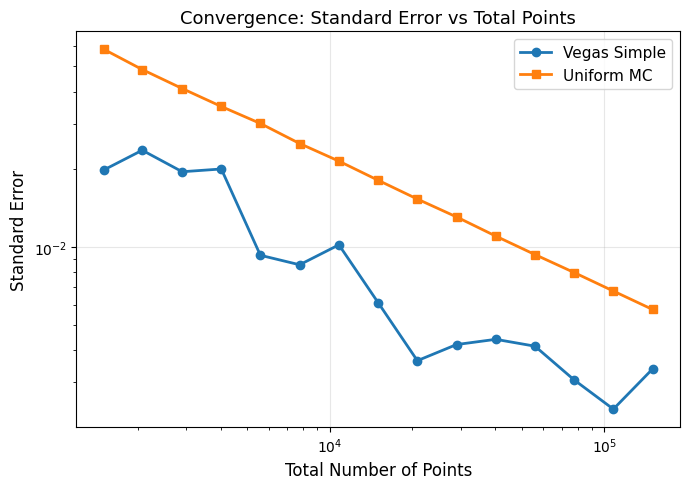

In [125]:
plt.figure(figsize=(7, 5))

plt.loglog(N_vals * iterations_fixed, vegas_std_errors, 'o-', label='Vegas Simple', linewidth=2)
plt.loglog(N_vals * iterations_fixed, mc_std_errors, 's-', label='Uniform MC', linewidth=2)

plt.xlabel('Total Number of Points', fontsize=12)
plt.ylabel('Standard Error', fontsize=12)
plt.title('Convergence: Standard Error vs Total Points', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('exercise1_convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualize Point Distribution Evolution

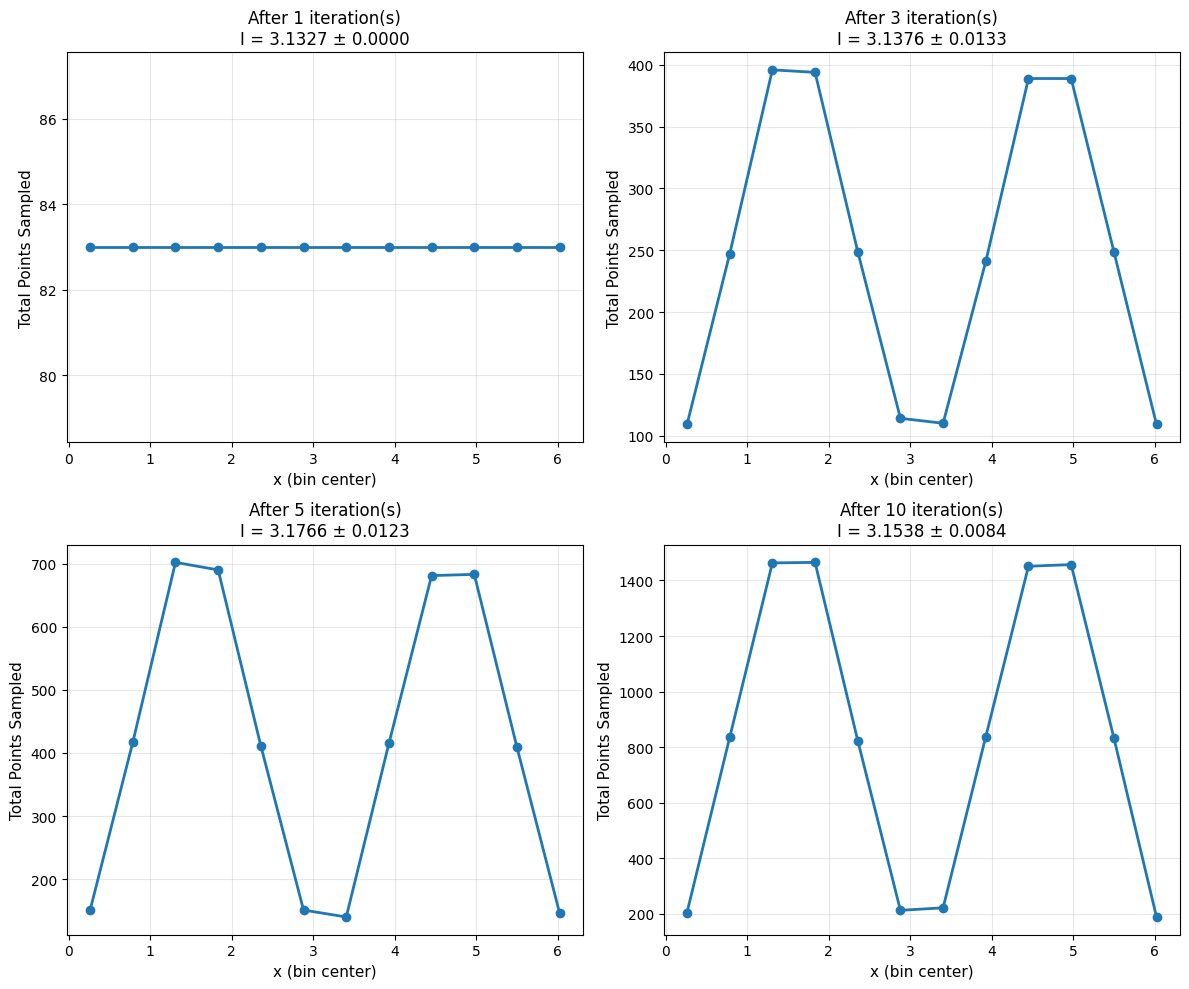

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
iteration_steps = [1, 3, 5, 10]
npoints = 1000

for idx, num_iter in enumerate(iteration_steps):
    ax = axes[idx // 2, idx % 2]

    I_est, err_est, points_dist = VegasSimple(lower, upper, f_test, npoints, bins, num_iter)

    bin_centers = lower + (np.arange(bins) + 0.5) * (upper - lower) / bins

    ax.plot(bin_centers, points_dist, marker='o', linewidth=2)
    ax.set_xlabel('x (bin center)', fontsize=11)
    ax.set_ylabel('Total Points Sampled', fontsize=11)
    ax.set_title(f'After {num_iter} iteration(s)\nI = {I_est:.4f} ± {err_est:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise1_point_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


The results are as expected, the peaks appear near where $\sin^2(x)$ is the largest


So:
$$
x \approx \frac{\pi}{2}, \quad x \approx \frac{3\pi}{2},
$$

---
# Exercise 2: Generate Different Distributions

Use uniform distribution to generate:
1. Exponential distribution: $p(x) = e^{-x}$
2. Gaussian distribution using Box-Muller transform

### Part 1: Exponential Distribution

Using inverse transform method:
- CDF: $F(x) = 1 - e^{-x}$
- Inverse: $F^{-1}(u) = -\ln(1-u) = -\ln(u)$

In [127]:
# Number of samples
n_samples = 100000

# Generate uniform random numbers
u = np.random.uniform(0, 1, n_samples)

# Transform to exponential distribution
x_exp = -np.log(u)

print("=== Exponential Distribution ===")
print(f"Number of samples: {n_samples}")
print(f"Mean (should be ~1): {np.mean(x_exp):.4f}")
print(f"Std (should be ~1): {np.std(x_exp):.4f}")

=== Exponential Distribution ===
Number of samples: 100000
Mean (should be ~1): 1.0024
Std (should be ~1): 1.0054


### Part 2: Gaussian Distribution

Using Box-Muller transform:
$$
x = \sqrt{-2\sigma^2 \ln r}\cos(2\pi s), \qquad
y = \sqrt{-2\sigma^2 \ln r}\sin(2\pi s).
$$

In [128]:
n_samples = 100000
sigma = 1.0

r = np.random.uniform(0, 1, n_samples)
s = np.random.uniform(0, 1, n_samples)

x = np.sqrt(-2 * sigma**2 * np.log(r)) * np.cos(2 * np.pi * s)
y = np.sqrt(-2 * sigma**2 * np.log(r)) * np.sin(2 * np.pi * s)

x_gaussian = x

print("=== Gaussian Distribution ===")
print(f"Number of samples: {n_samples}")
print(f"Mean (should be ~0): {np.mean(x_gaussian):.4f}")
print(f"Std (should be ~1): {np.std(x_gaussian):.4f}")


=== Gaussian Distribution ===
Number of samples: 100000
Mean (should be ~0): -0.0041
Std (should be ~1): 1.0017


### Plot Histograms with Theoretical Distributions

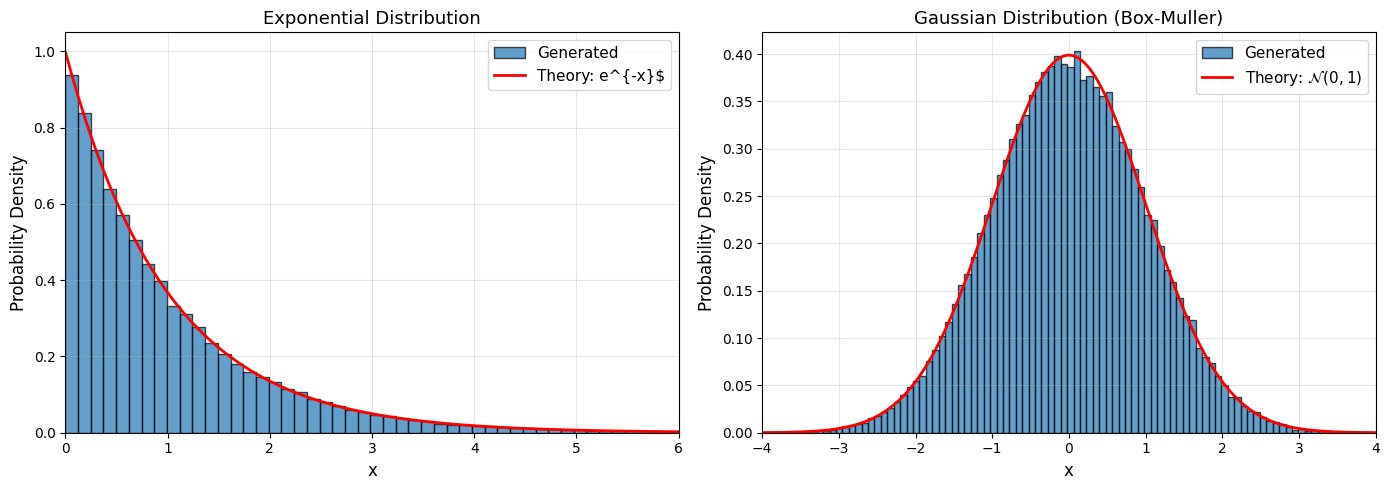

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exponential distribution
ax1.hist(x_exp, bins=100, density=True, alpha=0.7, edgecolor='black', label='Generated')
x_theory = np.linspace(0, 6, 200)
y_theory = np.exp(-x_theory)
ax1.plot(x_theory, y_theory, 'r-', linewidth=2, label='Theory: e^{-x}$')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Exponential Distribution', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 6)

# Gaussian distribution
ax2.hist(x_gaussian, bins=100, density=True, alpha=0.7, edgecolor='black', label='Generated')
x_theory2 = np.linspace(-4, 4, 200)
y_theory2 = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x_theory2**2)
ax2.plot(x_theory2, y_theory2, 'r-', linewidth=2, label=r'Theory: $\mathcal{N}(0,1)$')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('Gaussian Distribution (Box-Muller)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-4, 4)

plt.tight_layout()
plt.savefig('exercise2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()